# Классификация ансамблей по ключевым признакам

## По способу объединения предсказаний

### Усредняющие ансамбли (Averaging-based)

**Признак**: итоговое решение получается путём усреднения или голосования.

Виды:
- Простое усреднение (Mean / Majority Vote)
- Взвешенное усреднение

Свойства:
- Снижают дисперсию
- Почти не уменьшают смещение

### Обучаемые ансамбли (Meta-learning)

**Признак**: существует метамодель, обучающаяся на выходах базовых моделей.

Типичный представитель:
- Stacking
Свойства:
- Может снижать и bias, и variance
- Требует аккуратной валидации (out-of-fold)

## По способу получения разнообразия моделей

### За счёт данных (Data perturbation)

**Признак**: каждая модель обучается на модифицированной выборке.
Примеры:
- Bagging
- Random Forest (частично)

### За счёт алгоритма обучения

**Признак**: модели обучаются последовательно, каждая исправляет ошибки предыдущей.

Примеры:
- Boosting
- AdaBoost
- Gradient Boosting

### За счёт разных моделей (Heterogeneous)

**Признак**: используются разные типы алгоритмов.

Примеры:
- Logistic Regression + SVM + Trees → Stacking

## По структуре обучения

Параллельное обучение – Bagging, Random Forest

Последовательное обучение – Boosting

Двухуровневое – Stacking

## Упорядочивание ансамблей по возрастанию сложности самостоятельной реализации

От простого к сложному:
1. Простое усреднение / голосование (нет обучения ансамбля)
2. Bagging (bootstrap + независимое обучение)
3. Random Forest (bagging + случайные признаки + деревья)
4. AdaBoost (веса объектов, итеративное обучение)
5. Gradient Boosting (градиенты, функции потерь, shrinkage)
6. Stacking (out-of-fold схемы + метамодель)

# Импорт библиотек

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.ensemble import BaggingClassifier, BaggingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, r2_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

from methods.ensambles.bagging import CustomBaggingClassifier, CustomBaggingRegressor
from methods.ensambles.random_forest import CustomRandomForestClassifier, CustomRandomForestRegressor

In [2]:
RANDOM_STATE = 42

# Случайный лес

## Классификация

In [3]:
iris = load_iris()

In [4]:
X = iris.data[:, :2]
y = iris.target
feature_names = iris.feature_names[:2]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

In [5]:
params_rf = dict(
    n_estimators=120,
    max_depth=6,
    criterion="gini",
    max_features="sqrt",
    random_state=RANDOM_STATE,
)

In [6]:
custom_rf = CustomRandomForestClassifier(**params_rf).fit(X_train, y_train)
sklearn_rf = RandomForestClassifier(
    n_estimators=params_rf["n_estimators"],
    max_depth=params_rf["max_depth"],
    criterion=params_rf["criterion"],
    max_features=params_rf["max_features"],
    bootstrap=True,
    random_state=params_rf["random_state"],
).fit(X_train, y_train)

In [7]:
acc_custom = accuracy_score(y_test, custom_rf.predict(X_test))
acc_sklearn = accuracy_score(y_test, sklearn_rf.predict(X_test))
print(f"RandomForest | Custom accuracy: {acc_custom:.4f}")
print(f"RandomForest | sklearn accuracy: {acc_sklearn:.4f}")

RandomForest | Custom accuracy: 0.6667
RandomForest | sklearn accuracy: 0.7333


In [8]:
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400),
)
grid = np.c_[xx.ravel(), yy.ravel()]

Z_custom = custom_rf.predict(grid).reshape(xx.shape)
Z_sklearn = sklearn_rf.predict(grid).reshape(xx.shape)

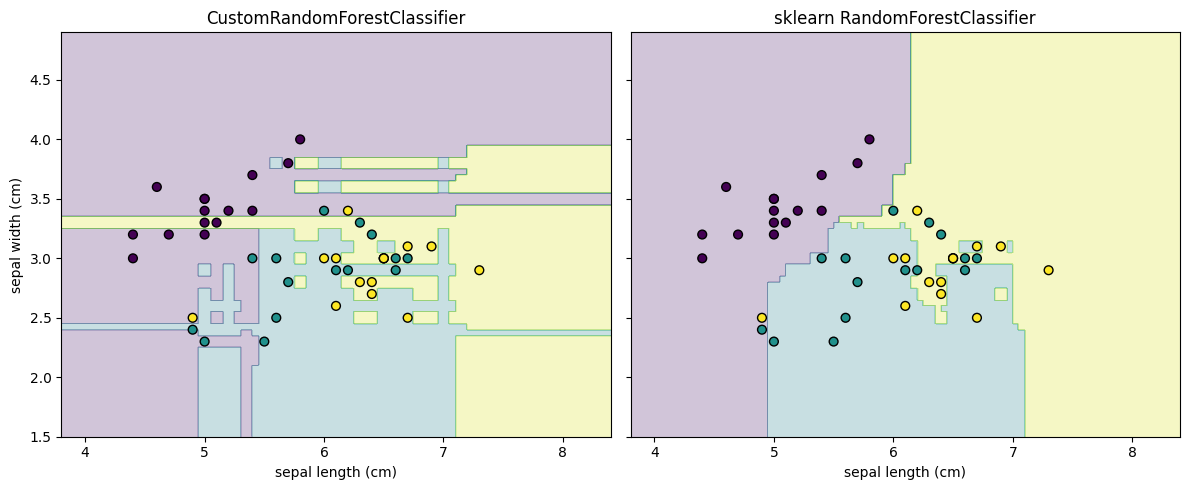

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
axes[0].contourf(xx, yy, Z_custom, alpha=0.25)
axes[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor="k", s=40)
axes[0].set_title("CustomRandomForestClassifier")
axes[0].set_xlabel(feature_names[0])
axes[0].set_ylabel(feature_names[1])

axes[1].contourf(xx, yy, Z_sklearn, alpha=0.25)
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor="k", s=40)
axes[1].set_title("sklearn RandomForestClassifier")
axes[1].set_xlabel(feature_names[0])

plt.tight_layout()
plt.show()

### Важности признаков


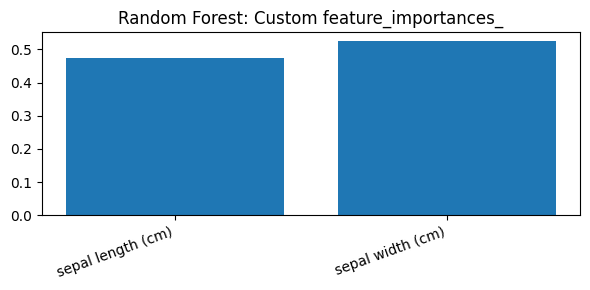

In [10]:
imp_rf = custom_rf.feature_importances_
plt.figure(figsize=(6, 3))
plt.bar(range(len(imp_rf)), imp_rf)
plt.xticks(range(len(imp_rf)), feature_names, rotation=20, ha="right")
plt.title("Random Forest: Custom feature_importances_")
plt.tight_layout()
plt.show()

## Регрессия


In [11]:
ds = fetch_california_housing()
Xr, yr = ds.data, ds.target

In [12]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    Xr, yr, test_size=0.25, random_state=RANDOM_STATE
)

In [13]:
params_rf_reg = dict(
    n_estimators=120,
    max_depth=None,
    criterion="squared_error",
    max_features=1.0,
    random_state=RANDOM_STATE,
)

In [14]:
custom_rf_reg = CustomRandomForestRegressor(**params_rf_reg).fit(X_train_r, y_train_r)
sklearn_rf_reg = RandomForestRegressor(
    n_estimators=params_rf_reg["n_estimators"],
    max_depth=params_rf_reg["max_depth"],
    criterion=params_rf_reg["criterion"],
    max_features=params_rf_reg["max_features"],
    bootstrap=True,
    random_state=params_rf_reg["random_state"],
).fit(X_train_r, y_train_r)

In [15]:
pred_custom = custom_rf_reg.predict(X_test_r)
pred_sklearn = sklearn_rf_reg.predict(X_test_r)

In [16]:
r2_custom = r2_score(y_test_r, pred_custom)
r2_sklearn = r2_score(y_test_r, pred_sklearn)
print(f"RandomForest | Custom R2: {r2_custom:.4f}")
print(f"RandomForest | sklearn R2: {r2_sklearn:.4f}")

RandomForest | Custom R2: 0.8070
RandomForest | sklearn R2: 0.8080


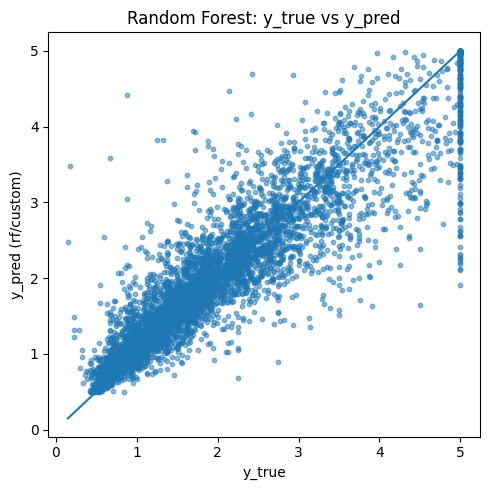

In [17]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test_r, pred_custom, s=10, alpha=0.5)
mn = min(y_test_r.min(), pred_custom.min())
mx = max(y_test_r.max(), pred_custom.max())
plt.plot([mn, mx], [mn, mx])
plt.xlabel("y_true")
plt.ylabel("y_pred (rf/custom)")
plt.title("Random Forest: y_true vs y_pred")
plt.tight_layout()
plt.show()

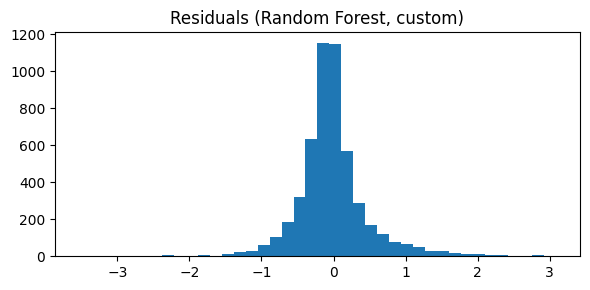

In [18]:
residuals = y_test_r - pred_custom
plt.figure(figsize=(6, 3))
plt.hist(residuals, bins=40)
plt.title("Residuals (Random Forest, custom)")
plt.tight_layout()
plt.show()

# Бэггинг

## Классификация

In [19]:
params_bag = dict(
    n_estimators=80,
    max_depth=6,
    criterion="gini",
    random_state=RANDOM_STATE,
)

In [20]:
custom_bag = CustomBaggingClassifier(**params_bag).fit(X_train, y_train)
sklearn_bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=params_bag["max_depth"],
        criterion=params_bag["criterion"],
        random_state=params_bag["random_state"],
    ),
    n_estimators=params_bag["n_estimators"],
    bootstrap=True,
    random_state=params_bag["random_state"],
).fit(X_train, y_train)

In [21]:
acc_custom = accuracy_score(y_test, custom_bag.predict(X_test))
acc_sklearn = accuracy_score(y_test, sklearn_bag.predict(X_test))
print(f"Bagging | Custom accuracy: {acc_custom:.4f}")
print(f"Bagging | sklearn accuracy: {acc_sklearn:.4f}")

Bagging | Custom accuracy: 0.7333
Bagging | sklearn accuracy: 0.7333


In [22]:
Z_custom = custom_bag.predict(grid).reshape(xx.shape)
Z_sklearn = sklearn_bag.predict(grid).reshape(xx.shape)

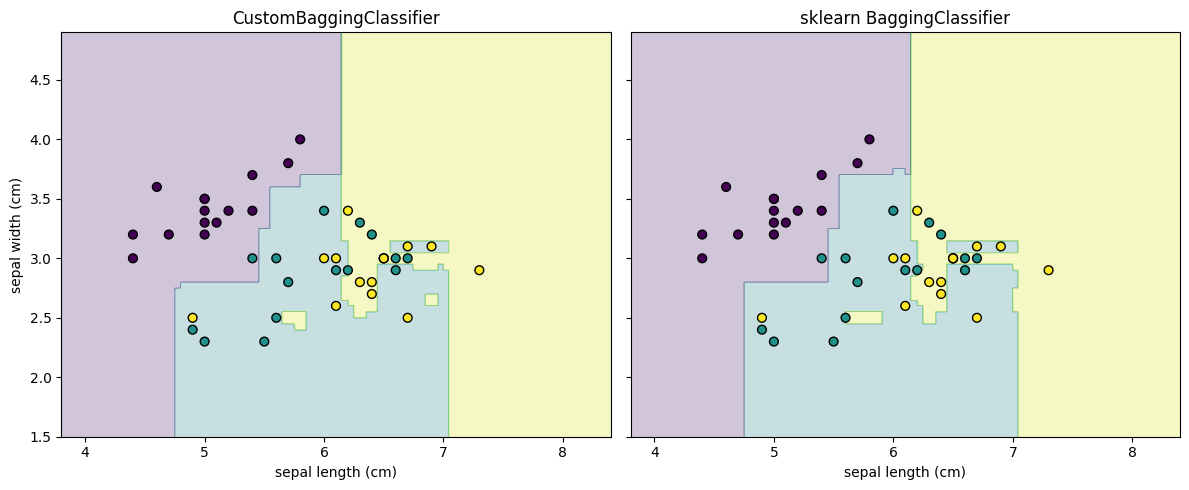

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
axes[0].contourf(xx, yy, Z_custom, alpha=0.25)
axes[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor="k", s=40)
axes[0].set_title("CustomBaggingClassifier")
axes[0].set_xlabel(feature_names[0])
axes[0].set_ylabel(feature_names[1])

axes[1].contourf(xx, yy, Z_sklearn, alpha=0.25)
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolor="k", s=40)
axes[1].set_title("sklearn BaggingClassifier")
axes[1].set_xlabel(feature_names[0])

plt.tight_layout()
plt.show()

### Важности признаков


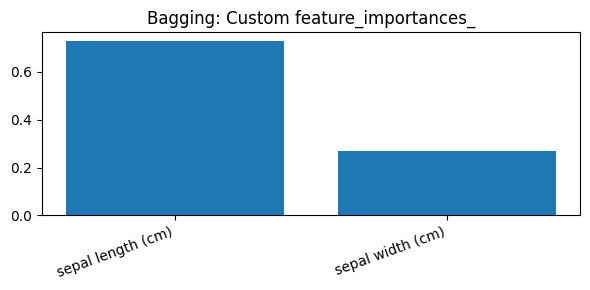

In [24]:
imp_bag = custom_bag.feature_importances_
plt.figure(figsize=(6, 3))
plt.bar(range(len(imp_bag)), imp_bag)
plt.xticks(range(len(imp_bag)), feature_names, rotation=20, ha="right")
plt.title("Bagging: Custom feature_importances_")
plt.tight_layout()
plt.show()

## Регрессия

In [25]:
params_bag_reg = dict(
    n_estimators=120,
    max_depth=None,
    criterion="squared_error",
    random_state=RANDOM_STATE,
)

In [26]:
custom_bag_reg = CustomBaggingRegressor(**params_bag_reg).fit(X_train_r, y_train_r)
sklearn_bag_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(
        max_depth=params_bag_reg["max_depth"],
        criterion=params_bag_reg["criterion"],
        random_state=params_bag_reg["random_state"],
    ),
    n_estimators=params_bag_reg["n_estimators"],
    bootstrap=True,
    random_state=params_bag_reg["random_state"],
).fit(X_train_r, y_train_r)

In [27]:
pred_custom = custom_bag_reg.predict(X_test_r)
pred_sklearn = sklearn_bag_reg.predict(X_test_r)

In [28]:
r2_custom = r2_score(y_test_r, pred_custom)
r2_sklearn = r2_score(y_test_r, pred_sklearn)
print(f"Bagging | Custom R2: {r2_custom:.4f}")
print(f"Bagging | sklearn R2: {r2_sklearn:.4f}")

Bagging | Custom R2: 0.8070
Bagging | sklearn R2: 0.8077


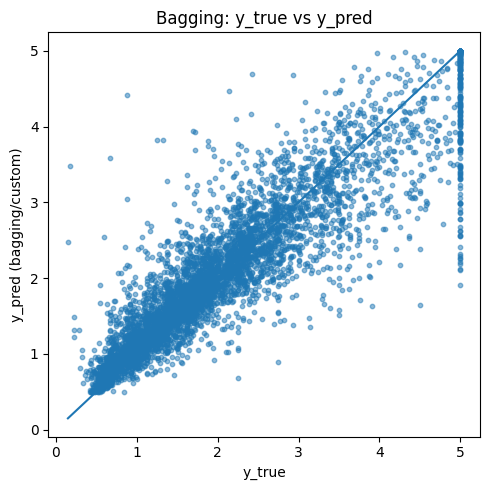

In [29]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test_r, pred_custom, s=10, alpha=0.5)
mn = min(y_test_r.min(), pred_custom.min())
mx = max(y_test_r.max(), pred_custom.max())
plt.plot([mn, mx], [mn, mx])
plt.xlabel("y_true")
plt.ylabel("y_pred (bagging/custom)")
plt.title("Bagging: y_true vs y_pred")
plt.tight_layout()
plt.show()